In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

c:\Users\Felipe Novais\.conda\envs\data_jobs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create plot: Distribution of United States Data Analyst Yearly Salaries

In [2]:
# filter dataframe
df_da = df.loc[
    (df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst") & (df["salary_year_avg"].notna()),
    ["job_country", "salary_year_avg"]
].reset_index(drop=True).sort_values(by="salary_year_avg").copy()

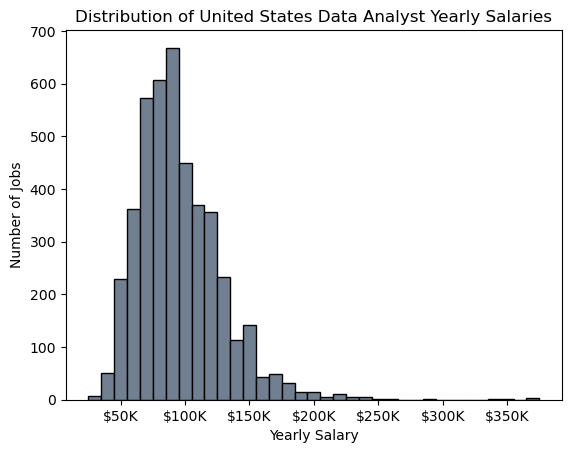

In [3]:
# create plot
df_da.plot(
    kind="hist",
    bins=35,
    edgecolor="black",
    legend=False,
    color="slategrey"
)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000):,}K"))

plt.title("Distribution of United States Data Analyst Yearly Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.show()